# Inspect the complete scene pipeline

This notebook creates one `SceneTrace` entirely in memory and audits every semantic boundary: pattern sampling, slot construction, class assignment, symbol realization, placement diagnostics, and final rendering.


In [61]:
from pathlib import Path
from pprint import pprint
import sys

from IPython.display import display

PROJECT_ROOT = next(
    root for root in (Path.cwd(), *Path.cwd().parents)
    if (root / '06_configs' / 'ontology.yaml').exists()
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.sampling import load_sampling_config
from scene import generate_scene_trace, load_audit_cases, load_scene_configuration
from scene.audit import (
    draw_assigned_graph,
    draw_final_overlay,
    draw_placed_graph,
    draw_realized_contact_sheet,
    draw_slot_graph,
    interaction_rows,
    node_rows,
)


## Configuration

Choose one deterministic case from `audit_cases.yaml`. The case selects its profile, pattern, seed, and optional stress overrides.


In [62]:
audit_case_id = 'grid_dense'
alpha_threshold = 0
contact_sheet_columns = 6


In [63]:
sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)
audit_cases = load_audit_cases(
    PROJECT_ROOT / '06_configs' / 'scene_sampling' / 'audit_cases.yaml'
)
if audit_case_id not in audit_cases:
    raise KeyError(f'Unknown audit case {audit_case_id!r}; choose from {list(audit_cases)}')
case = audit_cases[audit_case_id]
scene_config = load_scene_configuration(
    patterns_path=PROJECT_ROOT / '06_configs' / 'scene_sampling' / 'scene_patterns.yaml',
    profile_path=PROJECT_ROOT / '06_configs' / 'scene_sampling' / f'{case.profile}.yaml',
    metrics_path=PROJECT_ROOT / '06_configs' / 'symbol_metrics.yaml',
    sampling_config=sampling_config,
)
trace = generate_scene_trace(
    scene_config=scene_config,
    sampling_config=sampling_config,
    scene_seed=case.seed,
    scene_id=case.case_id,
    pattern=case.pattern,
    pattern_overrides=case.pattern_overrides,
    forced_role_classes=case.forced_role_classes,
    chart_scale=case.chart_scale,
    alpha_threshold=alpha_threshold,
)
print(f'Constructed {case.case_id!r} with {len(trace.slot_graph.nodes)} nodes.')


Constructed 'grid_dense' with 64 nodes.


## 1. Pattern sample

This is the complete upstream decision record used to construct the slot graph.


In [64]:
pprint({
    'scene_id': trace.pattern_sample.scene_id,
    'scene_seed': trace.pattern_sample.scene_seed,
    'profile': trace.pattern_sample.profile_name,
    'pattern': trace.pattern_sample.pattern_type,
    'parameters': dict(trace.pattern_sample.parameters),
    'chart_scale': trace.pattern_sample.chart_scale,
    'canvas_size_px': trace.pattern_sample.canvas_size_px,
    'config_identity': trace.pattern_sample.config_identity,
})


{'canvas_size_px': (1280, 1280),
 'chart_scale': 1.08109351835991,
 'config_identity': SceneConfigIdentity(patterns_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\scene_sampling\\scene_patterns.yaml',
                                        patterns_digest='0018de5b3c629b2f1906fdc4f32cc9246aef6545935708230d92d22b6d2eeefa',
                                        profile_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\scene_sampling\\exposure.yaml',
                                        profile_digest='318e775b28c01eca8b6ffc8dcc2e00c9e23e43038028d638c80b49ee92690755',
                                        metrics_path='C:\\Users\\xxxAn\\Desktop\\projects\\crochet-pattern-converter\\06_configs\\symbol_metrics.yaml',
                                        metrics_digest='36f6462aced49e6bc47ec4f59222f1c0bd1f6e6e59eda97ea57d6c9bb5a7314f'),
 'parameters': {'columns': 8,
                'pitch_x_px': 110.0,
            

## 2. Slot graph

Nodes have roles, structural positions, and relationships. They do not have assigned symbol classes yet.


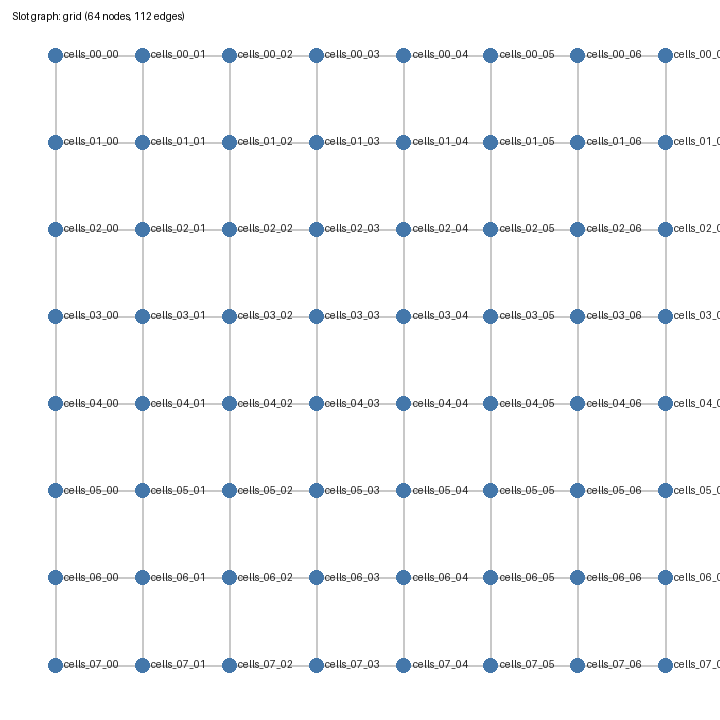

Role counts:
{'cells': 64}


In [65]:
display(draw_slot_graph(trace.slot_graph))
print('Role counts:')
role_counts = {}
for node in trace.slot_graph.nodes:
    role_counts[node.role] = role_counts.get(node.role, 0) + 1
pprint(role_counts)


## 3. Assigned graph

Each slot now has one concrete ontology class and stable seeds for class, symbol, and pose sampling.


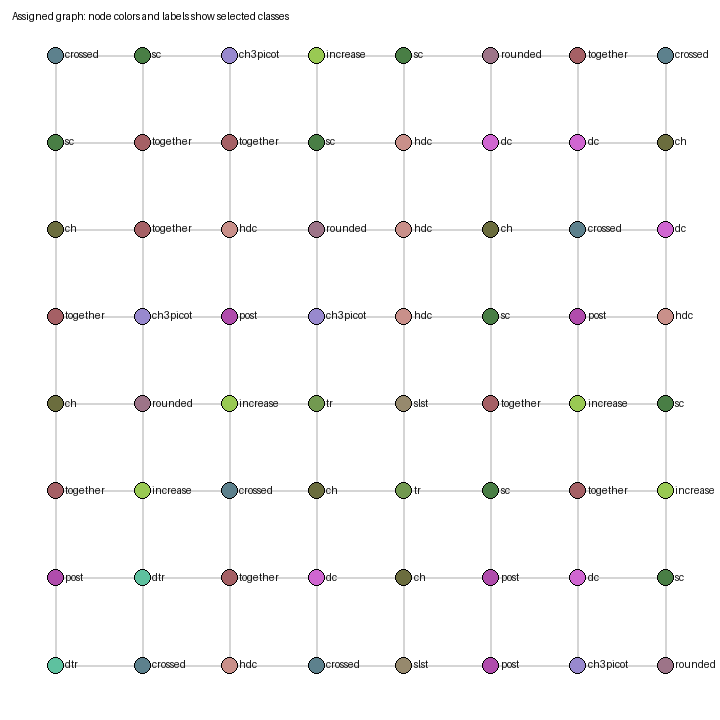

cells_00_00        role=cells   class=compound.crossed         symbol_seed=7593691581631718321
cells_00_01        role=cells   class=primitive.sc             symbol_seed=9325760122303034470
cells_00_02        role=cells   class=compound.ch3picot        symbol_seed=3324360974284179345
cells_00_03        role=cells   class=compound.increase        symbol_seed=8438662304932483888
cells_00_04        role=cells   class=primitive.sc             symbol_seed=16738394362868745890
cells_00_05        role=cells   class=compound.rounded         symbol_seed=12078284054370820510
cells_00_06        role=cells   class=compound.together        symbol_seed=6000472777604456514
cells_00_07        role=cells   class=compound.crossed         symbol_seed=13999902852091948404
cells_01_00        role=cells   class=primitive.sc             symbol_seed=17560543167125060754
cells_01_01        role=cells   class=compound.together        symbol_seed=12484805532214177937
cells_01_02        role=cells   class=compoun

In [66]:
display(draw_assigned_graph(trace.assigned_graph))
for node in trace.assigned_graph.nodes:
    print(
        f'{node.slot.slot_id:18} role={node.slot.role:7} '
        f'class={".".join(node.class_key):24} symbol_seed={node.symbol_seed}'
    )


## 4. Realized graph

Every node has an independently sampled upright SVG, transparent raster, and measured local OBB. Red rectangles are the local labels.


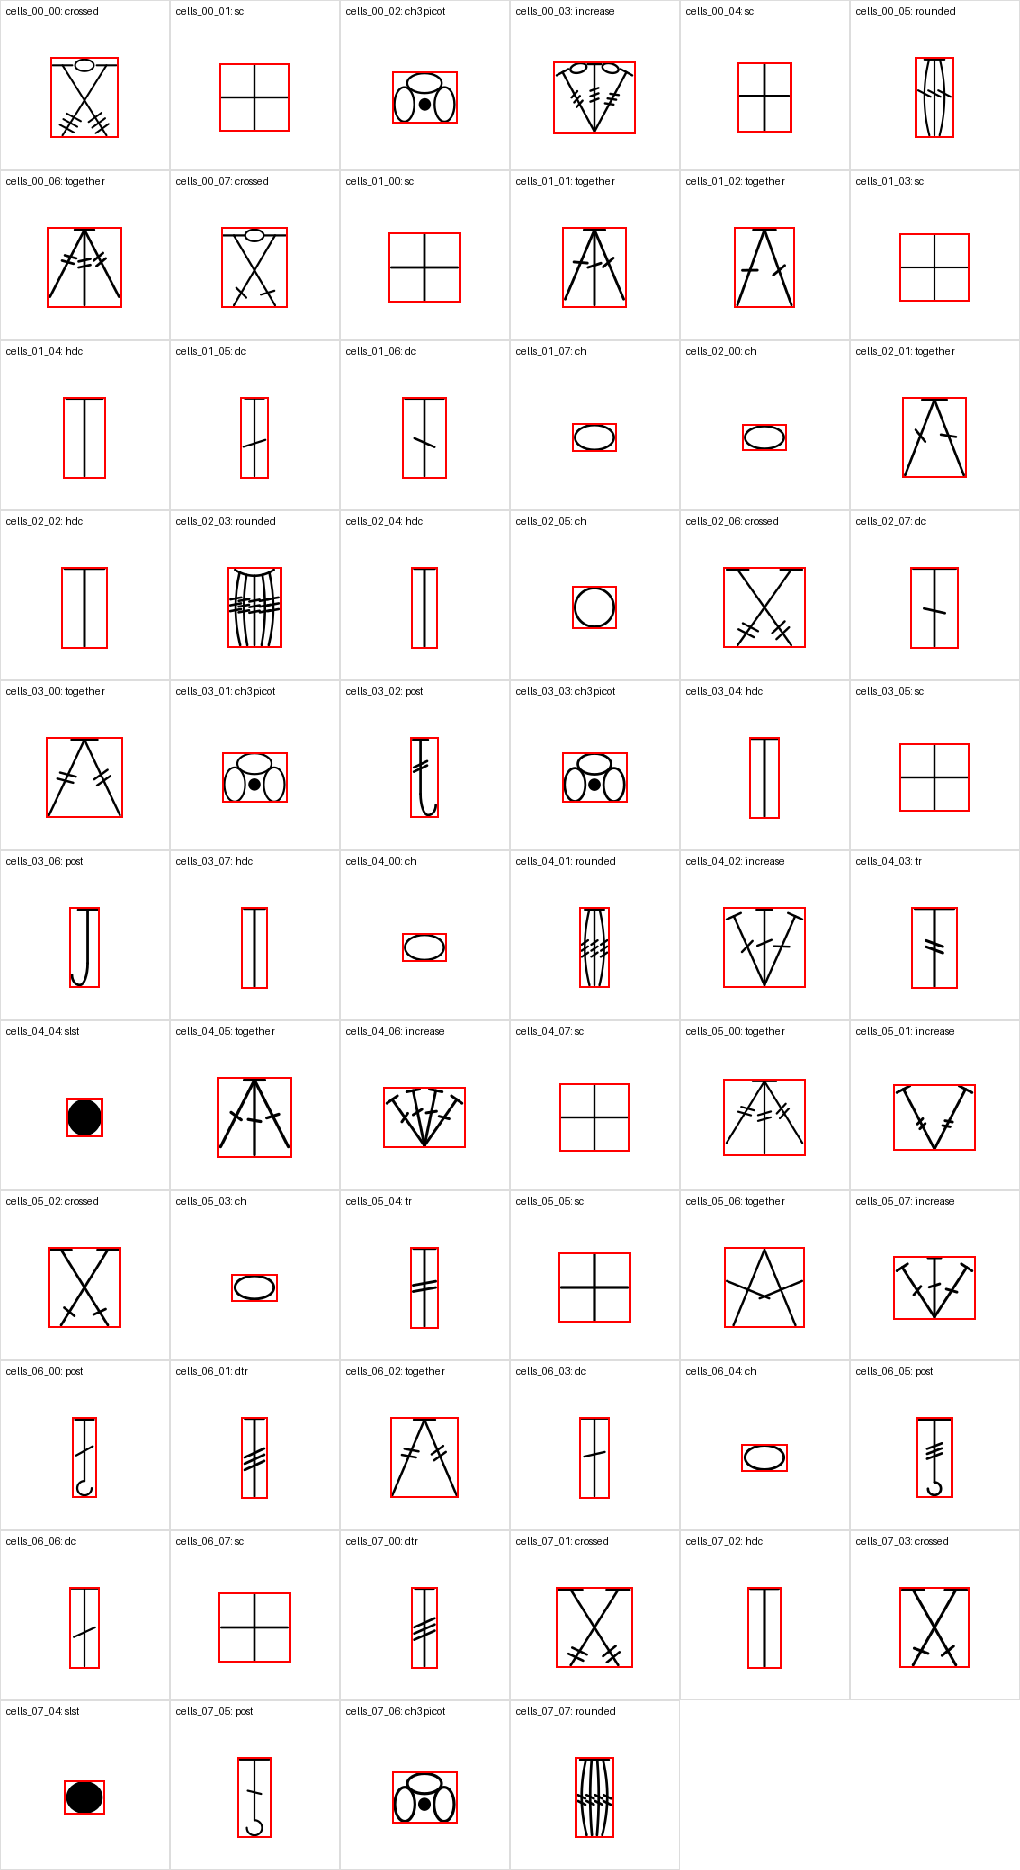

In [67]:
display(draw_realized_contact_sheet(
    trace.realized_graph, columns=contact_sheet_columns
))


## 5. Placed graph and interaction diagnostics

Pattern geometry supplies initial placement. Actual OBBs measure the resulting gaps and overlaps; the pipeline does not silently correct them.


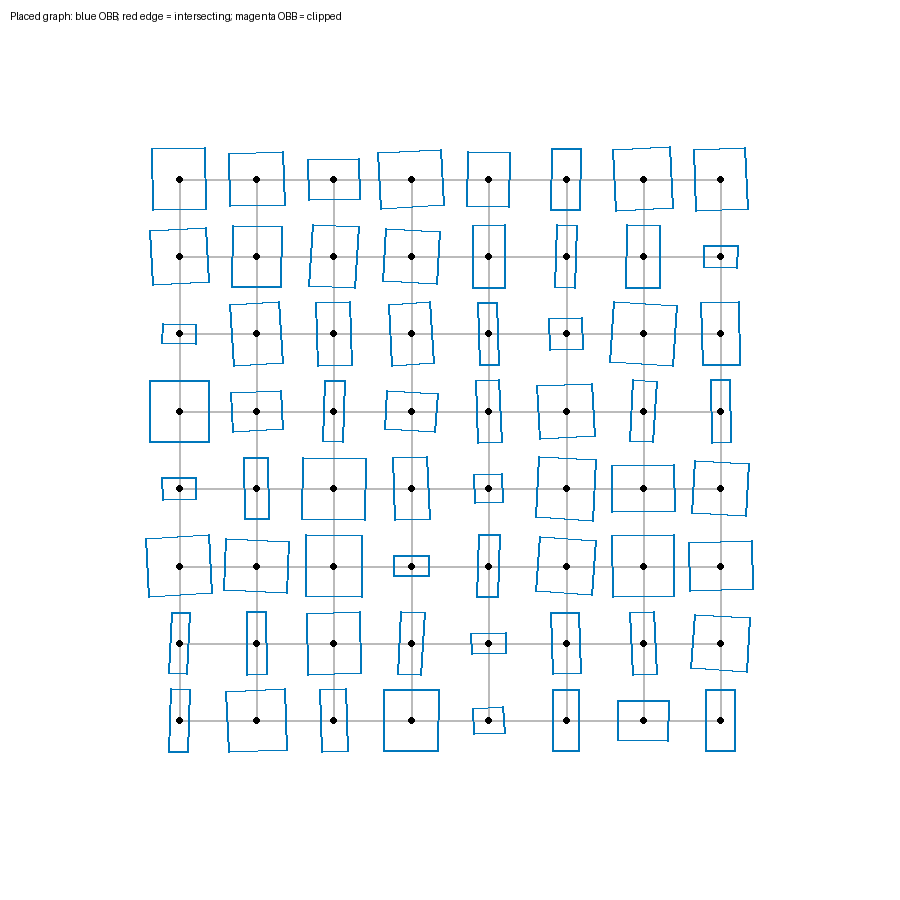

Warnings: none

Node placements:
[{'slot': 'cells_00_00',
  'role': 'cells',
  'class': 'compound.crossed',
  'center_px': (255.0, 255.0),
  'rotation_deg': -0.836,
  'visibility': 1.0,
  'symbol_seed': 7593691581631718321},
 {'slot': 'cells_00_01',
  'role': 'cells',
  'class': 'primitive.sc',
  'center_px': (365.0, 255.0),
  'rotation_deg': -1.423,
  'visibility': 1.0,
  'symbol_seed': 9325760122303034470},
 {'slot': 'cells_00_02',
  'role': 'cells',
  'class': 'compound.ch3picot',
  'center_px': (475.0, 255.0),
  'rotation_deg': -1.213,
  'visibility': 1.0,
  'symbol_seed': 3324360974284179345},
 {'slot': 'cells_00_03',
  'role': 'cells',
  'class': 'compound.increase',
  'center_px': (585.0, 255.0),
  'rotation_deg': -3.129,
  'visibility': 1.0,
  'symbol_seed': 8438662304932483888},
 {'slot': 'cells_00_04',
  'role': 'cells',
  'class': 'primitive.sc',
  'center_px': (695.0, 255.0),
  'rotation_deg': 1.1,
  'visibility': 1.0,
  'symbol_seed': 16738394362868745890},
 {'slot': 'cell

In [68]:
display(draw_placed_graph(trace.placed_graph))
print('Warnings:', trace.placed_graph.warnings or 'none')
print('\nNode placements:')
pprint(node_rows(trace.placed_graph), sort_dicts=False)


In [69]:
rows = interaction_rows(trace.placed_graph)
intersections = [row for row in rows if row['intersects']]
tightest = sorted(rows, key=lambda row: row['signed_gap_px'])[:25]
print(f'Edges: {len(rows)}; intersecting OBB pairs: {len(intersections)}')
print('Tightest 25 edge relationships:')
pprint(tightest, sort_dicts=False)


Edges: 112; intersecting OBB pairs: 0
Tightest 25 edge relationships:
[{'edge': 'v_01_06',
  'relationship': 'vertical_neighbor',
  'source': 'cells_01_06',
  'target': 'cells_02_06',
  'distance_px': 110.0,
  'signed_gap_px': 17.916,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'v_02_06',
  'relationship': 'vertical_neighbor',
  'source': 'cells_02_06',
  'target': 'cells_03_06',
  'distance_px': 110.0,
  'signed_gap_px': 18.324,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'h_05_00',
  'relationship': 'horizontal_neighbor',
  'source': 'cells_05_00',
  'target': 'cells_05_01',
  'distance_px': 110.0,
  'signed_gap_px': 18.511,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'v_01_02',
  'relationship': 'vertical_neighbor',
  'source': 'cells_01_02',
  'target': 'cells_02_02',
  'distance_px': 110.0,
  'signed_gap_px': 18.637,
  'overlap_area_px2': 0.0,
  'intersects': False},
 {'edge': 'v_00_06',
  'relationship': 'vertical_neighbor',
  's

## 6. Final rendered scene

The final scene SVG is rasterized once. Red polygons show the transformed scene-space OBBs; blue text shows the target class.


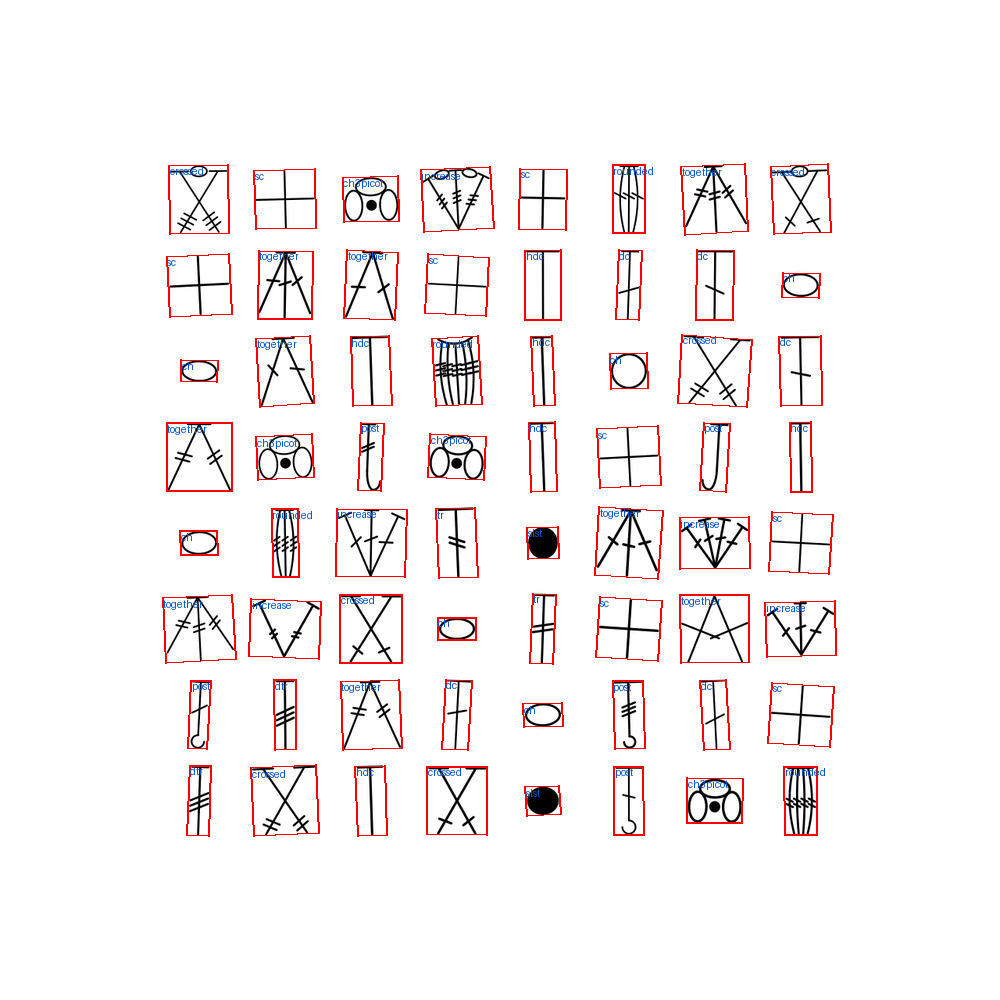

YOLO labels: 64
First five labels:
10 0.16981413 0.16526908 0.22762047 0.16442573 0.22862337 0.23316842 0.17081703 0.23401177
2 0.25474076 0.17027755 0.31409745 0.16880326 0.31557174 0.22815995 0.25621505 0.22963424
12 0.34327638 0.17714659 0.39795162 0.17598857 0.39891112 0.22129091 0.34423588 0.22244893
8 0.42100154 0.16989192 0.48964902 0.16613878 0.49306096 0.22854558 0.42441348 0.23229872
2 0.52090168 0.16832061 0.56620583 0.16919062 0.56503582 0.23011689 0.51973167 0.22924688


In [70]:
display(draw_final_overlay(
    trace.placed_graph, trace.rendered_scene.png_bytes
))
print(f'YOLO labels: {len(trace.rendered_scene.yolo_labels)}')
print('First five labels:')
for label in trace.rendered_scene.yolo_labels[:5]:
    print(label)
